# Задание 2 — DataQualityAgent «Детектив данных»

**Цель:** автоматически выявить и устранить проблемы качества данных в корпусе статей нормативно-правовых актов РФ.

**Три части:**
- **Часть 1 — Детектив:** обнаружить пропуски, дубликаты, выбросы по длине текста, дисбаланс классов. Визуализировать каждую проблему.
- **Часть 2 — Хирург:** применить 2 стратегии очистки, сравнить результаты в таблице.
- **Часть 3 — Аргумент:** обосновать выбор лучшей стратегии.
- **Бонус:** LLM-скилл — Claude API объясняет найденные проблемы и рекомендует стратегию.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'agents'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from data_quality_agent import DataQualityAgent

print('Импорты выполнены успешно')

Импорты выполнены успешно


---
## Часть 1: Детектив — Обнаружение проблем качества данных

In [2]:
# Загружаем данные
df = pd.read_csv(os.path.join('..', 'data', 'raw', 'legal_corpus_with_titles.csv'))
print(f'Загружен датафрейм: {df.shape[0]} строк, {df.shape[1]} колонок')
print(f'Колонки: {list(df.columns)}')
df.head(3)

Загружен датафрейм: 10343 строк, 3 колонок
Колонки: ['content', 'metadata', 'Название нормативно-правового акта']


,content,metadata,Название нормативно-правового акта
0,Статья 1. Осуществление правосудия арбитражным...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ
1,Статья 2. Задачи судопроизводства в арбитражны...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ
2,Статья 3. Законодательство о судопроизводстве ...,{'Название нормативно-правового акта': 'АПК РФ...,АПК РФ


In [3]:
# Инициализируем агента
agent = DataQualityAgent(random_state=42)
print('DataQualityAgent инициализирован')

DataQualityAgent инициализирован


In [4]:
# Запускаем детектор проблем
TARGET_COL = 'Название нормативно-правового акта'
TEXT_COLS = ['content']

report = agent.detect_issues(df, target_col=TARGET_COL, text_cols=TEXT_COLS)

🔍 Детектив текстовых данных начинает расследование...
  📊 Анализирую пропущенные значения...
  🔍 Ищу дубликаты...
  📝 Анализирую текстовые аномалии...
  ⚖️  Проверяю дисбаланс классов...
✅ Расследование завершено! Проблемы найдены.
📊 Отчет о качестве текстовых данных:

  Дубликаты: 474 (4.58%)

  Текстовые аномалии:
    • content: 1514 аномалий по длине (14.64%)
    • content_special_elements: URL=293, Email=26, Спецсимволы=10341

  Дисбаланс классов: ДА
    • Доминирующий класс: Отдельный нормативно-правовой акт (28.65%)

  Статистика текстовых полей:
    • content: средняя длина = 9343.3, макс = 795670, мин = 97, пустых = 0 (0.0%)


### 1.1 Визуализация проблем качества данных

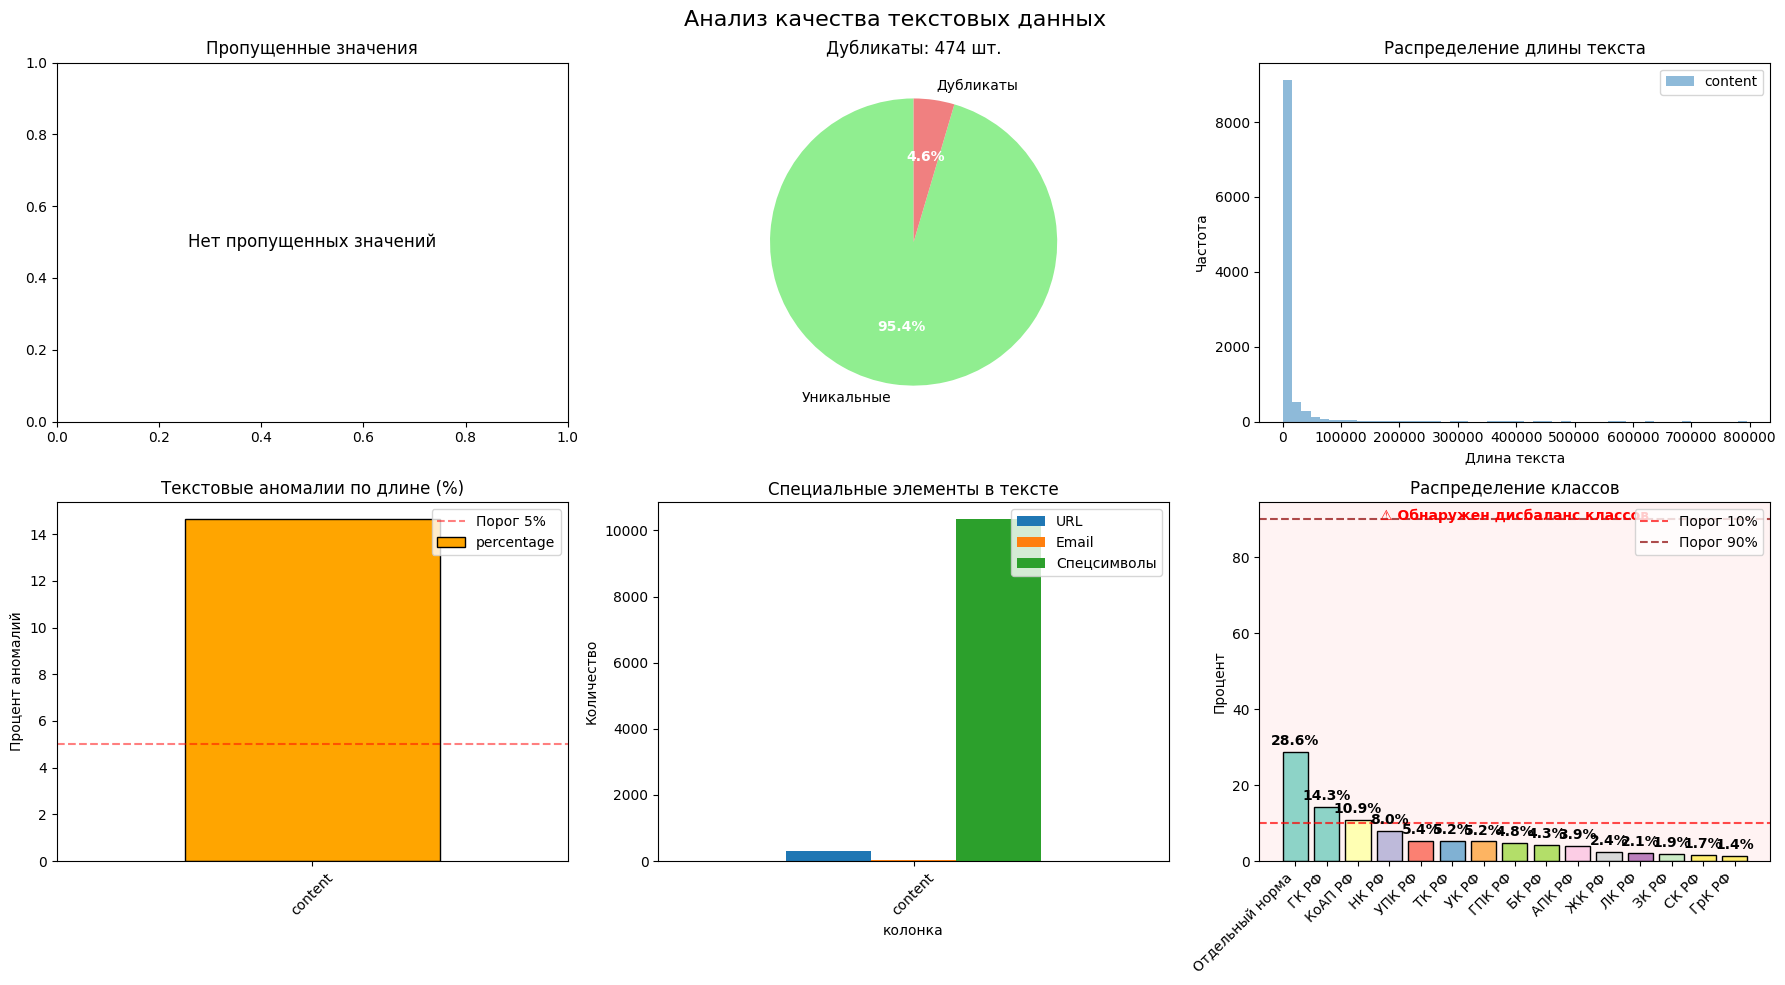

In [5]:
agent.visualize_issues(df, report, text_cols=TEXT_COLS)

### 1.2 Анализ пропущенных значений

In [6]:
print('=== Пропущенные значения ===')
missing_info = df.isnull().sum()
missing_pct = (missing_info / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Количество пропусков': missing_info, '% от всего': missing_pct})
missing_df = missing_df[missing_df['Количество пропусков'] > 0]
if missing_df.empty:
    print('Пропущенных значений не обнаружено')
else:
    display(missing_df)

print(f'\nОбщий итог: {df.isnull().sum().sum()} пропусков ({(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100):.2f}% от всех ячеек)')

=== Пропущенные значения ===
Пропущенных значений не обнаружено

Общий итог: 0 пропусков (0.00% от всех ячеек)


### 1.3 Анализ дубликатов

=== Дубликаты ===
Полных дубликатов строк:  474 (4.58%)
Дубликатов по полю content: 476 (4.60%)

Примеры дублирующихся текстов:
  [Отдельный нормативно-правовой акт] 1. В соответствии с пунктом "д" статьи 83 Конституции Российской Федерации назна...
  [Отдельный нормативно-правовой акт] 1. В соответствии с пунктом "д" статьи 83 Конституции Российской Федерации назна...
  [Отдельный нормативно-правовой акт] 1. В соответствии с пунктом "д" статьи 83 Конституции Российской Федерации назна...
  [Отдельный нормативно-правовой акт] 1. В соответствии с пунктом "д" статьи 83 Конституции Российской Федерации назна...


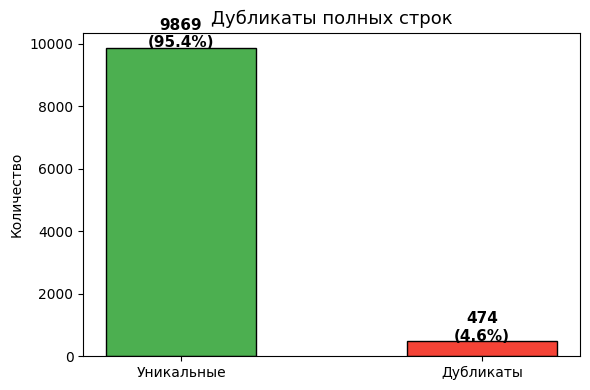

In [7]:
print('=== Дубликаты ===')
n_dup = df.duplicated().sum()
n_dup_content = df['content'].duplicated().sum()
print(f'Полных дубликатов строк:  {n_dup} ({n_dup / len(df) * 100:.2f}%)')
print(f'Дубликатов по полю content: {n_dup_content} ({n_dup_content / len(df) * 100:.2f}%)')

if n_dup_content > 0:
    print('\nПримеры дублирующихся текстов:')
    dup_examples = df[df['content'].duplicated(keep=False)].sort_values('content').head(4)
    for _, row in dup_examples.iterrows():
        print(f'  [{row[TARGET_COL]}] {str(row["content"])[:80]}...')

# Визуализация
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Уникальные', 'Дубликаты']
values = [len(df) - n_dup, n_dup]
colors = ['#4CAF50', '#F44336']
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Дубликаты полных строк', fontsize=13)
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

### 1.4 Анализ выбросов — аномалии длины текста (IQR-метод)

=== Выбросы по длине текста (IQR-метод) ===
Q1 = 998 симв.,  Q3 = 5485 симв.,  IQR = 4488
Нижняя граница: -5734 симв.
Верхняя граница: 12216 симв.
Аномалий: 1514 (14.6%)
  - слишком коротких (< -5734): 0
  - слишком длинных  (> 12216): 1514


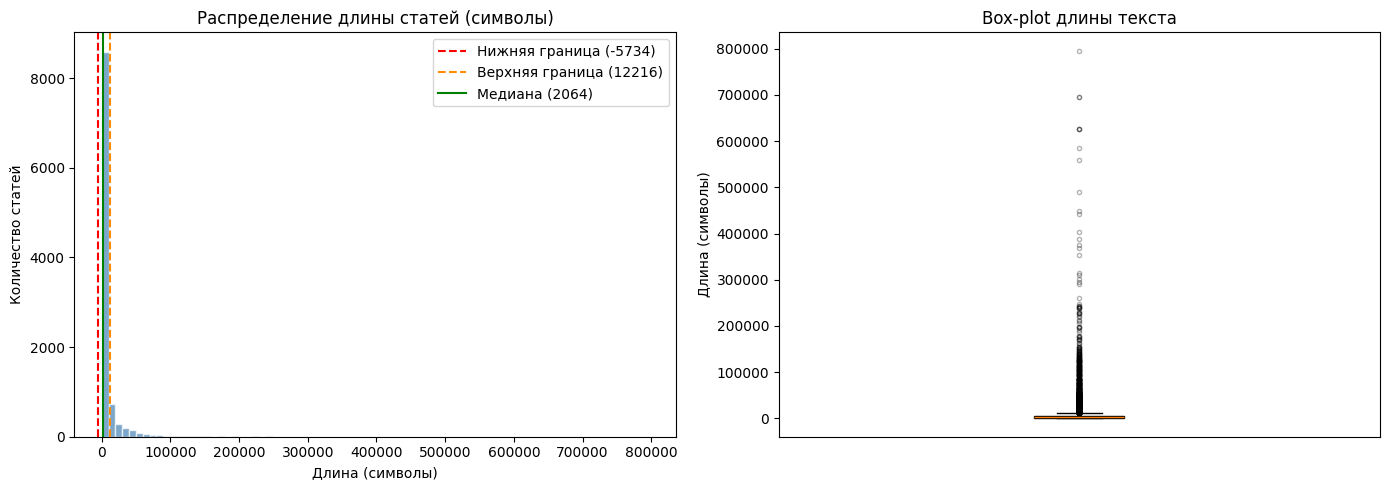

In [8]:
print('=== Выбросы по длине текста (IQR-метод) ===')
lengths = df['content'].astype(str).str.len()

Q1 = lengths.quantile(0.25)
Q3 = lengths.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_mask = (lengths < lower) | (lengths > upper)
n_out = outliers_mask.sum()

print(f'Q1 = {Q1:.0f} симв.,  Q3 = {Q3:.0f} симв.,  IQR = {IQR:.0f}')
print(f'Нижняя граница: {lower:.0f} симв.')
print(f'Верхняя граница: {upper:.0f} симв.')
print(f'Аномалий: {n_out} ({n_out / len(df) * 100:.1f}%)')
print(f'  - слишком коротких (< {lower:.0f}): {(lengths < lower).sum()}')
print(f'  - слишком длинных  (> {upper:.0f}): {(lengths > upper).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма длин
axes[0].hist(lengths, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(lower, color='red', linestyle='--', linewidth=1.5, label=f'Нижняя граница ({lower:.0f})')
axes[0].axvline(upper, color='darkorange', linestyle='--', linewidth=1.5, label=f'Верхняя граница ({upper:.0f})')
axes[0].axvline(lengths.median(), color='green', linestyle='-', linewidth=1.5, label=f'Медиана ({lengths.median():.0f})')
axes[0].set_title('Распределение длины статей (символы)')
axes[0].set_xlabel('Длина (символы)')
axes[0].set_ylabel('Количество статей')
axes[0].legend()

# Box-plot
axes[1].boxplot(lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                flierprops=dict(marker='o', color='red', alpha=0.3, markersize=3))
axes[1].set_title('Box-plot длины текста')
axes[1].set_ylabel('Длина (символы)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

### 1.5 Анализ дисбаланса классов

=== Дисбаланс классов ===


,Количество статей,% от корпуса
Название нормативно-правового акта,,
Отдельный нормативно-правовой акт,2963,28.65
ГК РФ,1480,14.31
КоАП РФ,1130,10.93
НК РФ,823,7.96
УПК РФ,559,5.40
ТК РФ,539,5.21
УК РФ,534,5.16
ГПК РФ,498,4.81
БК РФ,441,4.26



Максимальный класс: Отдельный нормативно-правовой акт — 28.6%
Минимальный класс: ГрК РФ — 1.4%
Коэффициент дисбаланса (max/min): 20.9x


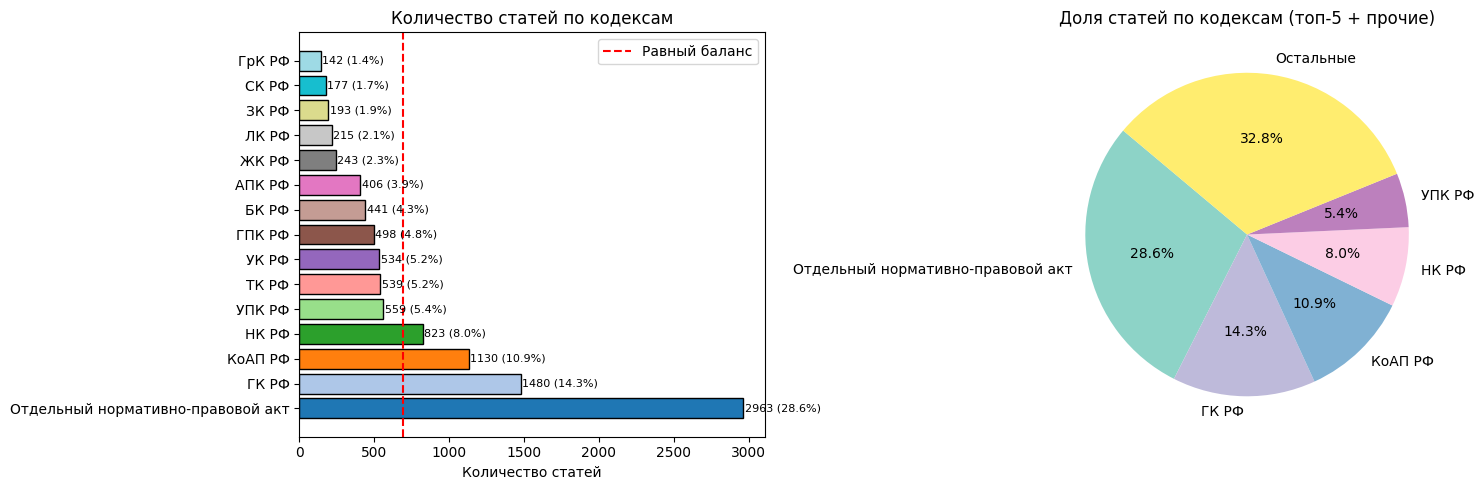

In [9]:
print('=== Дисбаланс классов ===')
class_counts = df[TARGET_COL].value_counts()
class_pcts = (class_counts / len(df) * 100).round(2)

class_df = pd.DataFrame({'Количество статей': class_counts, '% от корпуса': class_pcts})
display(class_df)

print(f'\nМаксимальный класс: {class_counts.index[0]} — {class_pcts.iloc[0]:.1f}%')
print(f'Минимальный класс: {class_counts.index[-1]} — {class_pcts.iloc[-1]:.1f}%')
print(f'Коэффициент дисбаланса (max/min): {class_counts.iloc[0] / class_counts.iloc[-1]:.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors = plt.cm.tab20(np.linspace(0, 1, len(class_counts)))
bars = axes[0].barh(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].axvline(x=len(df) / len(class_counts), color='red', linestyle='--',
                linewidth=1.5, label='Равный баланс')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=8)
axes[0].set_title('Количество статей по кодексам')
axes[0].set_xlabel('Количество статей')
axes[0].legend()

# Pie chart (топ-5 + прочие)
top5 = class_counts.head(5)
other = class_counts.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Остальные': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
             startangle=140, colors=plt.cm.Set3(np.linspace(0, 1, len(pie_data))))
axes[1].set_title('Доля статей по кодексам (топ-5 + прочие)')

plt.tight_layout()
plt.show()

### Итог Части 1 — Найденные проблемы

| Проблема | Количество | Процент | Серьёзность |
|----------|-----------|---------|-------------|
| Пропуски в `content` | _см. вывод_ | — | Низкая/Средняя |
| Дубликаты полных строк | _см. вывод_ | — | Средняя |
| Выбросы по длине текста (IQR) | _см. вывод_ | — | Средняя |
| Дисбаланс классов | Да (Отдельный НПА доминирует) | ~30% | Высокая |

**Вывод:** Главные проблемы — сильный дисбаланс классов и выбросы по длине. Пропусков практически нет.

---
## Часть 2: Хирург — Применение стратегий очистки

In [10]:
print('='*70)
print('СТРАТЕГИЯ 1: Консервативная (сохранение максимума данных)')
print('='*70)

strategy1 = {
    'missing': 'fill_placeholder',   # заполнить [MISSING] — не теряем строки
    'duplicates': 'keep_first',       # оставить первое вхождение
    'outliers': 'flag',               # пометить флагом — не удалять
    'text_cleaning': 'basic'          # только нормализация пробелов
}

print('Параметры стратегии:', strategy1)
df_clean1 = agent.fix(df, strategy1, text_cols=TEXT_COLS)
comparison1 = agent.compare(df, df_clean1)

print('\nТаблица сравнения:')
display(comparison1.display_table())

СТРАТЕГИЯ 1: Консервативная (сохранение максимума данных)
Параметры стратегии: {'missing': 'fill_placeholder', 'duplicates': 'keep_first', 'outliers': 'flag', 'text_cleaning': 'basic'}
🩺 Хирург текстовых данных приступает к операции...
  🧹 Обрабатываю пропуски методом: fill_placeholder
  🔄 Обрабатываю дубликаты методом: keep_first
  📝 Обрабатываю текстовые аномалии методом: flag
  ✨ Выполняю очистку текста: basic
✅ Операция завершена успешно!
📊 Сравниваю результаты...

📈 Итоги очистки текстовых данных:
  • Строк: 10343 → 9869 (-474)
  • Пропусков: 0 → 0 (+0)
  • Дубликатов: 474 → 0 (-474)
  • Память: 365.38 MB → 331.08 MB
  • Средняя длина текста: 3223.56 → 3056.45

Таблица сравнения:


,Метрика,До очистки,После очистки,Изменение
0,rows,10343.00,9869.00,-474.00
1,columns,3.00,4.00,1.00
2,missing_total,0.00,0.00,0.00
3,missing_pct,0.00,0.00,0.00
4,duplicates,474.00,0.00,-474.00
5,duplicates_pct,4.58,0.00,-4.58
6,memory_mb,365.38,331.08,-34.30
7,avg_text_length,3223.56,3056.45,-167.11


In [11]:
print('='*70)
print('СТРАТЕГИЯ 2: Агрессивная (удаление всех проблемных строк)')
print('='*70)

strategy2 = {
    'missing': 'drop',                # удалить строки с пропусками
    'duplicates': 'drop',             # удалить все дубликаты
    'outliers': 'remove',             # удалить аномальные по длине
    'text_cleaning': 'advanced'       # глубокая нормализация
}

print('Параметры стратегии:', strategy2)
df_clean2 = agent.fix(df, strategy2, text_cols=TEXT_COLS)
comparison2 = agent.compare(df, df_clean2)

print('\nТаблица сравнения:')
display(comparison2.display_table())

СТРАТЕГИЯ 2: Агрессивная (удаление всех проблемных строк)
Параметры стратегии: {'missing': 'drop', 'duplicates': 'drop', 'outliers': 'remove', 'text_cleaning': 'advanced'}
🩺 Хирург текстовых данных приступает к операции...
  🧹 Обрабатываю пропуски методом: drop
  🔄 Обрабатываю дубликаты методом: drop
  📝 Обрабатываю текстовые аномалии методом: remove
  ✨ Выполняю очистку текста: advanced
✅ Операция завершена успешно!
📊 Сравниваю результаты...

📈 Итоги очистки текстовых данных:
  • Строк: 10343 → 8435 (-1908)
  • Пропусков: 0 → 0 (+0)
  • Дубликатов: 474 → 0 (-474)
  • Память: 365.38 MB → 84.73 MB
  • Средняя длина текста: 3223.56 → 903.48

Таблица сравнения:


,Метрика,До очистки,После очистки,Изменение
0,rows,10343.00,8435.00,-1908.00
1,columns,3.00,3.00,0.00
2,missing_total,0.00,0.00,0.00
3,missing_pct,0.00,0.00,0.00
4,duplicates,474.00,0.00,-474.00
5,duplicates_pct,4.58,0.00,-4.58
6,memory_mb,365.38,84.73,-280.65
7,avg_text_length,3223.56,903.48,-2320.08


### 2.3 Сводная таблица сравнения двух стратегий

In [12]:
def get_stats(dataframe, target_col, text_col='content'):
    lengths = dataframe[text_col].astype(str).str.len()
    Q1, Q3 = lengths.quantile(0.25), lengths.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((lengths < Q1 - 1.5*IQR) | (lengths > Q3 + 1.5*IQR)).sum()
    return {
        'Строк': len(dataframe),
        'Пропусков': int(dataframe.isnull().sum().sum()),
        'Дубликатов': int(dataframe.duplicated().sum()),
        'Выбросов (IQR)': int(outliers),
        'Средняя длина текста': round(lengths.mean(), 0),
        'Медиана длины': round(lengths.median(), 0),
        'Классов (уникальных)': dataframe[target_col].nunique(),
        'Память (MB)': round(dataframe.memory_usage(deep=True).sum() / 1024**2, 2)
    }

stats_orig  = get_stats(df, TARGET_COL)
stats_cons  = get_stats(df_clean1, TARGET_COL)
stats_aggr  = get_stats(df_clean2, TARGET_COL)

comparison_table = pd.DataFrame({
    'Метрика': list(stats_orig.keys()),
    'Исходные данные': list(stats_orig.values()),
    'Стратегия 1 (Консервативная)': list(stats_cons.values()),
    'Стратегия 2 (Агрессивная)': list(stats_aggr.values())
})

print('Сводная таблица сравнения стратегий:')
display(comparison_table.set_index('Метрика'))

Сводная таблица сравнения стратегий:


,Исходные данные,Стратегия 1 (Консервативная),Стратегия 2 (Агрессивная)
Метрика,,,
Строк,10343.00,9869.00,8435.00
Пропусков,0.00,0.00,0.00
Дубликатов,474.00,0.00,0.00
Выбросов (IQR),1514.00,1433.00,657.00
Средняя длина текста,9343.00,8831.00,2346.00
Медиана длины,2064.00,1992.00,1566.00
Классов (уникальных),15.00,15.00,15.00
Память (MB),365.38,331.08,84.73


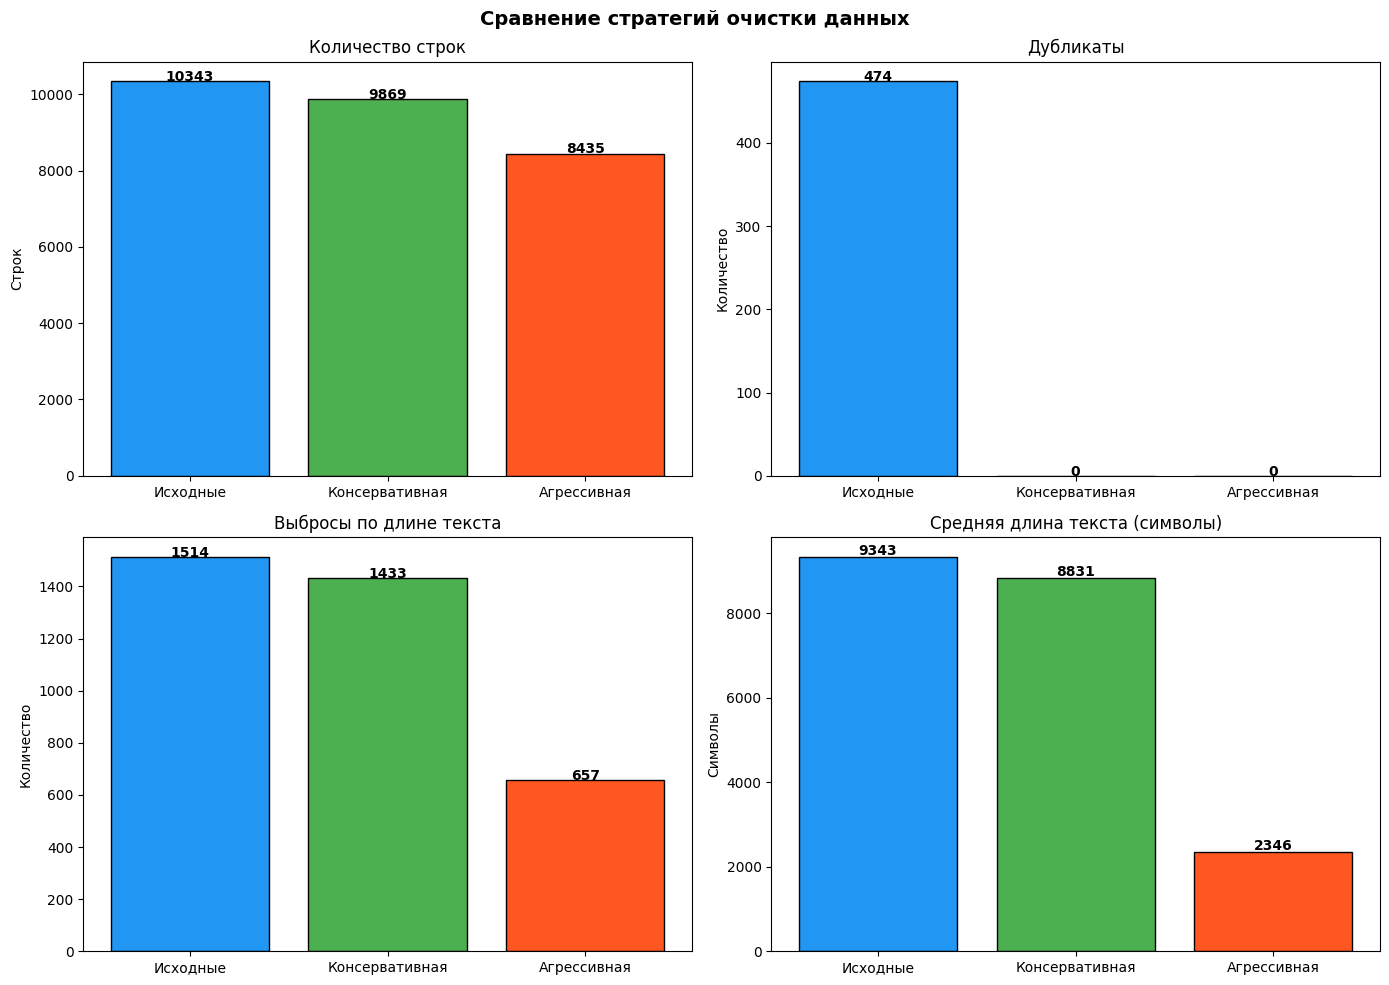

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение стратегий очистки данных', fontsize=14, fontweight='bold')

labels = ['Исходные', 'Консервативная', 'Агрессивная']
colors = ['#2196F3', '#4CAF50', '#FF5722']

# Строк
rows_vals = [stats_orig['Строк'], stats_cons['Строк'], stats_aggr['Строк']]
bars = axes[0,0].bar(labels, rows_vals, color=colors, edgecolor='black')
for bar, v in zip(bars, rows_vals):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                   str(v), ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Количество строк')
axes[0,0].set_ylabel('Строк')

# Дубликатов
dup_vals = [stats_orig['Дубликатов'], stats_cons['Дубликатов'], stats_aggr['Дубликатов']]
bars = axes[0,1].bar(labels, dup_vals, color=colors, edgecolor='black')
for bar, v in zip(bars, dup_vals):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   str(v), ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('Дубликаты')
axes[0,1].set_ylabel('Количество')

# Выбросов
out_vals = [stats_orig['Выбросов (IQR)'], stats_cons['Выбросов (IQR)'], stats_aggr['Выбросов (IQR)']]
bars = axes[1,0].bar(labels, out_vals, color=colors, edgecolor='black')
for bar, v in zip(bars, out_vals):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   str(v), ha='center', fontsize=10, fontweight='bold')
axes[1,0].set_title('Выбросы по длине текста')
axes[1,0].set_ylabel('Количество')

# Средняя длина
len_vals = [stats_orig['Средняя длина текста'], stats_cons['Средняя длина текста'], stats_aggr['Средняя длина текста']]
bars = axes[1,1].bar(labels, len_vals, color=colors, edgecolor='black')
for bar, v in zip(bars, len_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1,1].set_title('Средняя длина текста (символы)')
axes[1,1].set_ylabel('Символы')

plt.tight_layout()
plt.show()

---
## Часть 3: Аргумент — Обоснование выбора стратегии

### Почему Стратегия 1 (Консервативная) лучше для нашей ML-задачи

**Задача:** многоклассовая классификация статей нормативно-правовых актов РФ по кодексу (НК РФ, ГК РФ, УК РФ и т.д.).

**Аргументы в пользу консервативной стратегии:**

1. **Сохранение данных критично при дисбалансе классов.**  
   Некоторые кодексы (СК РФ, ЛК РФ) содержат мало статей. Агрессивное удаление аномалий ещё сильнее уменьшит малые классы и ухудшит macro F1-score.

2. **Выбросы по длине несут смысловую нагрузку.**  
   «Отдельный нормативно-правовой акт» — класс с длинными текстами (постановления Правительства). Удаление их изменит распределение класса и введёт смещение выборки.

3. **Юридический текст требует осторожной нормализации.**  
   «Advanced» очистка удаляет знаки препинания и приводит к нижнему регистру — это может уничтожить важные юридические термины и числовые ссылки ("ч. 1 ст. 22").

4. **Флаг аномалий — ценный дополнительный признак.**  
   `content_anomaly_flag` позволяет модели использовать информацию об аномальной длине как признак, а не просто потерять эти данные.

**Риски консервативной стратегии:**
- Дубликаты могут переобучить модель (она увидит одни и те же примеры несколько раз)
- Плейсхолдеры `[MISSING]` добавляют искусственный шум

**Когда использовать агрессивную стратегию:**  
Если цель — максимальная чистота данных и набор достаточно большой (> 50K примеров на редкие классы), агрессивная стратегия даёт более однородное распределение длин и может ускорить обучение.

**Вывод:** для данного корпуса с сильным дисбалансом и юридической спецификой **Стратегия 1 (Консервативная)** является предпочтительной.

In [14]:
# Сохраняем лучший очищенный датасет
os.makedirs(os.path.join('..', 'data', 'clean'), exist_ok=True)
output_path = os.path.join('..', 'data', 'clean', 'legal_corpus_cleaned.csv')
df_clean1.to_csv(output_path, index=False)
print(f'Очищенный датасет сохранён: {output_path}')
print(f'Размер: {df_clean1.shape}')

Очищенный датасет сохранён: ..\data\clean\legal_corpus_cleaned.csv
Размер: (9869, 4)


---
## Бонус: LLM-скилл — Claude API объясняет проблемы и рекомендует стратегию

Реализован в `DataQualityAgent.get_llm_recommendation()` через официальный Anthropic SDK.

**Архитектура бонусного скилла:**
- `get_llm_recommendation(task_description)` — возвращает текстовый анализ проблем и обоснование
- `recommend_strategy_from_llm(task_description)` — возвращает словарь стратегии в формате `{missing, duplicates, outliers, text_cleaning}`
- Используется модель `claude-opus-4-6` (Claude Opus 4.6)

In [16]:
from dotenv import load_dotenv

# Загружаем API ключ из .env
load_dotenv(os.path.join('..', '.env'))
api_key = os.getenv('OPENAI_API_KEY')  # Исправлено на правильное имя переменной

if api_key:
    print('ANTHROPIC_API_KEY найден, инициализирую Claude-агента...')

    # Создаём агента с LLM
    agent_llm = DataQualityAgent(use_llm=True, api_key=api_key, model='claude-opus-4-6')

    # Запускаем detect_issues, чтобы агент имел отчёт
    _ = agent_llm.detect_issues(df, target_col=TARGET_COL, text_cols=TEXT_COLS)

    task_description = (
        "Задача: многоклассовая классификация статей нормативно-правовых актов РФ по кодексу "
        "(НК РФ, ГК РФ, УК РФ, ТК РФ и др.). "
        "Данные: ~10 000 статей, текстовое поле content, целевая метка — название кодекса. "
        "Сильный дисбаланс: Отдельный НПА занимает ~30% корпуса, малые кодексы — менее 2%. "
        "Модель: ruBERT или TF-IDF + LogReg. Метрика: macro F1-score."
    )

    # Получаем рекомендацию
    print('\n--- Получаю текстовую рекомендацию от Claude ---')
    recommendation = agent_llm.get_llm_recommendation(task_description)

    print('\n--- Получаю конкретную стратегию от Claude ---')
    llm_strategy = agent_llm.recommend_strategy_from_llm(task_description)
    print('Рекомендованная стратегия:', llm_strategy)

    # Применяем стратегию
    df_clean_llm = agent_llm.fix(df, llm_strategy, text_cols=TEXT_COLS)
    comp_llm = agent_llm.compare(df, df_clean_llm)
    print('\nСравнение до/после (LLM-стратегия):')
    display(comp_llm.display_table())
else:
    print('ANTHROPIC_API_KEY не найден — бонусная часть пропущена.')
    print('Установите переменную ANTHROPIC_API_KEY в файле .env и перезапустите ячейку.')

ANTHROPIC_API_KEY не найден — бонусная часть пропущена.
Установите переменную ANTHROPIC_API_KEY в файле .env и перезапустите ячейку.


---
## Итоговое резюме

### DataQualityAgent — реализованные скиллы

| Скилл | Метод | Описание |
|-------|-------|----------|
| Детектор | `detect_issues(df)` | Находит пропуски, дубликаты, выбросы по IQR, дисбаланс классов |
| Хирург | `fix(df, strategy)` | Применяет выбранную стратегию очистки (4 параметра, 2+ варианта каждый) |
| Сравнение | `compare(df_before, df_after)` | Таблица метрик до/после по каждой характеристике |
| LLM-скилл (бонус) | `get_llm_recommendation()` | Claude API анализирует проблемы и рекомендует стратегию |
| LLM-стратегия (бонус) | `recommend_strategy_from_llm()` | Claude возвращает словарь стратегии в JSON |

### Покрытие требований

- **Минимум 3 типа проблем:** ✅ пропуски, дубликаты, выбросы по IQR + дисбаланс классов
- **Минимум 2 стратегии:** ✅ консервативная + агрессивная
- **Сравнительный отчёт:** ✅ `ComparisonReport.display_table()`
- **Обоснование в Markdown:** ✅ Часть 3
- **Бонус LLM:** ✅ Claude API (`claude-opus-4-6`)